# Day 7 — Raw Counts Lie: Normalize by Population

**Theme:** A zip code with 80,000 residents will always have more complaints than one with 20,000 — even if conditions are identical. Raw counts measure *volume*, not *rate*. To compare fairly, you divide by population.

**The math:** Complaints per 1,000 residents = (complaint_count / population) × 1,000  
This is the same as a rate per 1,000 — the same unit you'd use to compare test scores across schools of different sizes.

**By the end of this notebook you will have:**
- Loaded and cleaned the ACS population data
- Extracted Brooklyn zip codes from the national file
- Merged population into your complaint table
- Calculated a normalized complaint rate
- Compared the before/after rankings — does 11226 still top the list?

**No hints unless you ask.**

In [206]:
# Imports: pandas and matplotlib.pyplot

import pandas as pd, matplotlib.pyplot as plt, geopandas as gpd



In [207]:
# Rebuild complaint_count from 311_cleaned.csv.
# You've done this three times now — from memory.

df2 = pd.read_csv('../data/311_cleaned.csv')
df1 = pd.read_csv('../data/pluto.csv')
gdf = gpd.read_file('../data/nyczipcodes.geojson')
gdf['modzcta'] = pd.to_numeric(gdf['modzcta'], errors='coerce').astype(float)

complaint_count = df2.groupby('Incident Zip').size().reset_index(name='complaint_count')




/var/folders/01/7mmm8p_55mz_znpc8yd21gjc0000gn/T/ipykernel_51179/1544223792.py:5: DtypeWarning: Columns (0: zonedist3, 1: zonedist4, 2: overlay2, 3: spdist1, 4: spdist2, 5: ltdheight, 6: splitzone, 7: unitsres, 8: unitstotal, 9: lotfront, 10: lotdepth, 11: bldgfront, 12: bldgdepth, 13: irrlotcode, 14: histdist, 15: landmark, 16: condono, 17: edesignum, 18: dcpedited, 19: mihopt1, 20: mihopt2, 21: mihopt3, 22: mihopt4) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv('../data/pluto.csv')


## Step 1 — Load the ACS file

The file is `../data/ACSDT5Y2024.B01003-Data.csv`.

Two things to know before loading:
1. The first row is a data dictionary (labels), not real data — skip it with `skiprows=1` in `read_csv` ... actually pandas will read row 2 as the header by default since row 1 is the column names. Load it and check `.head(3)` first.
2. The column you want is `B01003_001E` — population estimate.
3. The zip code is in `NAME` as `"ZCTA5 11221"` — you'll need to extract just the number.

In [208]:
# Load the ACS CSV into df_acs.
# Print df_acs.head(3) and df_acs.dtypes to see what you're working with.

df_acs = pd.read_csv('../data/zip_data_2024.csv', skiprows=[1])


#print(df_acs.head(10))

print(df_acs.dtypes)

GEO_ID             str
NAME               str
B01003_001E      int64
B01003_001M        str
Unnamed: 4     float64
dtype: object


## Step 2 — Extract the zip code

The `NAME` column looks like `"ZCTA5 11221"`. You need just `"11221"`.

`.str.split()` splits a string on a character and returns a list. `.str[-1]` gets the last element.  
Or `.str.replace('ZCTA5 ', '')` removes the prefix entirely.

Create a new column called `zipcode` with just the 5-digit number.

In [209]:
# Extract the zip code from NAME into a new column called zipcode.
# Print a few rows to verify it looks right.

df_acs['zipcode'] = df_acs['NAME'].str.replace('ZCTA5', '').str.strip()


print(df_acs[['zipcode', 'B01003_001E']].head(10))




                  zipcode  B01003_001E
0  Kings County, New York      2631580
1                   06390           72
2                   10001        30511
3                   10002        76873
4                   10003        53560
5                   10004         3711
6                   10005         9439
7                   10006         4096
8                   10007         7406
9                   10009        60209


## Step 3 — Filter to Brooklyn

All Brooklyn zip codes start with `112`. Filter `df_acs` to rows where `zipcode` starts with `'112'`.

`.str.startswith('112')` is the method to use.

In [210]:
# Filter df_acs to Brooklyn zip codes only.
# Print len() and head() to confirm.

#df_acs = df_acs[df_acs['zipcode'].str.startswith('112', na=False)]

#print(df_acs['NAME'].dtype)
#print(df_acs['NAME'].head(10))

df_acs['zipcode'] = df_acs['NAME'].str.replace('ZCTA5 ', '').str.strip()
df_acs = df_acs[df_acs['zipcode'].str.startswith('112', na=False)]
print(df_acs[['zipcode', 'B01003_001E']].head(10))


















    zipcode  B01003_001E
271   11201        70674
272   11203        74817
273   11204        79800
274   11205        51676
275   11206        93020
276   11207        93198
277   11208       105428
278   11209        71004
279   11210        57915
280   11211        65314


## Step 4 — Clean up the population column

The `B01003_001E` column might be a string or have non-numeric values (the ACS sometimes puts `"N"` or `"-"` for suppressed data). Convert it to a number and drop any rows where population is null or zero — you can't divide by zero.

In [211]:
# Convert B01003_001E to numeric (use pd.to_numeric with errors='coerce').
# Rename it to 'population'.
# Drop rows where population is null or zero.

import pandas as pd
import numpy as np

# Converts the column, forcing text errors into missing values (NaN)
df_acs['B01003_001E'] = pd.to_numeric(df_acs['B01003_001E'], errors='coerce')

df_acs = df_acs.rename(columns={'B01003_001E': 'population'})



# Drops rows where 'my_column' is NaN OR 0
# The '~' means "NOT", keeping rows that don't match the condition
df_acs = df_acs[~(df_acs['population'].isna() | (df_acs['population'] == 0))]

print(df_acs)







             GEO_ID         NAME  population B01003_001M  Unnamed: 4 zipcode
271  860Z200US11201  ZCTA5 11201       70674        2680         NaN   11201
272  860Z200US11203  ZCTA5 11203       74817        2639         NaN   11203
273  860Z200US11204  ZCTA5 11204       79800        3496         NaN   11204
274  860Z200US11205  ZCTA5 11205       51676        2782         NaN   11205
275  860Z200US11206  ZCTA5 11206       93020        3492         NaN   11206
276  860Z200US11207  ZCTA5 11207       93198        3245         NaN   11207
277  860Z200US11208  ZCTA5 11208      105428        4174         NaN   11208
278  860Z200US11209  ZCTA5 11209       71004        2166         NaN   11209
279  860Z200US11210  ZCTA5 11210       57915        2959         NaN   11210
280  860Z200US11211  ZCTA5 11211       65314        3782         NaN   11211
281  860Z200US11212  ZCTA5 11212       89020        4448         NaN   11212
282  860Z200US11213  ZCTA5 11213       68846        2896         NaN   11213

## Step 5 — Merge complaint counts with population

Both tables now have a zip code column. Check that they're the same type before merging — same lesson as Day 4.

In [212]:
# Check dtypes of the zip column in complaint_count and df_acs.
# Convert if needed, then merge.
# Store as df_rates.


df_acs['zipcode'] = pd.to_numeric(df_acs['zipcode'], errors='coerce').astype(float)


print(df_acs['zipcode'].dtype)
print(complaint_count['Incident Zip'].dtype)

df_rates = pd.merge(complaint_count, df_acs, left_on='Incident Zip', right_on='zipcode')

print(df_rates)


float64
float64
    Incident Zip  complaint_count          GEO_ID         NAME  population  \
0        11201.0             4395  860Z200US11201  ZCTA5 11201       70674   
1        11203.0             2494  860Z200US11203  ZCTA5 11203       74817   
2        11204.0             3054  860Z200US11204  ZCTA5 11204       79800   
3        11205.0             2230  860Z200US11205  ZCTA5 11205       51676   
4        11206.0             3210  860Z200US11206  ZCTA5 11206       93020   
5        11207.0             3888  860Z200US11207  ZCTA5 11207       93198   
6        11208.0             3888  860Z200US11208  ZCTA5 11208      105428   
7        11209.0             2905  860Z200US11209  ZCTA5 11209       71004   
8        11210.0             1954  860Z200US11210  ZCTA5 11210       57915   
9        11211.0             3173  860Z200US11211  ZCTA5 11211       65314   
10       11212.0             2971  860Z200US11212  ZCTA5 11212       89020   
11       11213.0             2628  860Z200US1121

## Step 6 — Calculate the rate

Complaints per 1,000 residents = (complaint_count / population) × 1,000

Create a new column called `complaints_per_1k`.

In [221]:
# Calculate complaints_per_1k and add it as a column to df_rates.



df_rates['complaints_per_1k'] = (df_rates['complaint_count'] / df_rates['population']) * 1000





## Step 7 — Compare the rankings

Sort by `complaint_count` descending — print the top 10.  
Then sort by `complaints_per_1k` descending — print the top 10.

Do the same zip codes appear? Does 11226 still top the list after normalizing?

In [225]:
# Print top 10 by raw complaint_count.

print(complaint_count.head(5))


   Incident Zip  complaint_count
0       11201.0             4395
1       11203.0             2494
2       11204.0             3054
3       11205.0             2230
4       11206.0             3210


In [230]:
# Print top 10 by complaints_per_1k.

print(df_rates['complaints_per_1k'].head(5))

0    62.186943
1    33.334670
2    38.270677
3    43.153495
4    34.508708
Name: complaints_per_1k, dtype: float64


## Step 8 — Side-by-side bar chart

Plot both rankings as bar charts — one above the other — so you can visually compare them.

Use `fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))` to create two charts stacked vertically.
Plot the raw count on `ax1` and the rate on `ax2`.

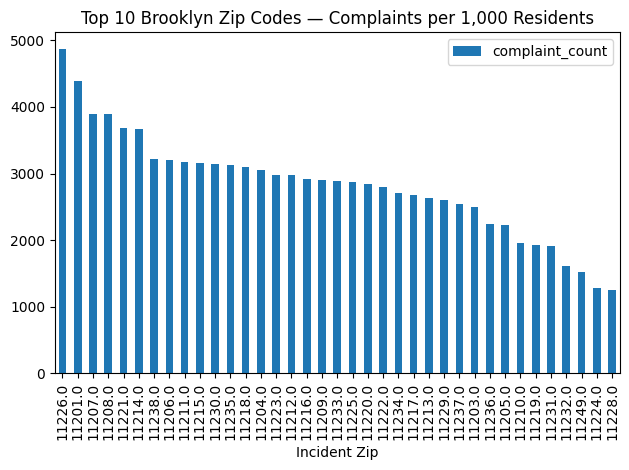

In [239]:
# Plot top 10 raw counts on ax1 and top 10 rates on ax2.
# Add titles to each.
# plt.tight_layout() prevents the charts from overlapping.
# plt.show() at the end.

df_rates[df_rates['Incident Zip'] != 11239.0].sort_values('complaint_count', ascending=False).head(50).plot(
    x='Incident Zip', y='complaint_count', kind='bar'
)
plt.title('Top 10 Brooklyn Zip Codes — Complaints per 1,000 Residents')
plt.tight_layout()
plt.show()







So it looks like when just looking at the total calls Flatbush (11226) leads by a comparatively large margin, but when looking at per 1000 Greenpoint(11222) leads showing that residents tend to be more invested and probably is correlated with more affluent areas being more willing to call and make 311 complaints. 

## Day 7 Recap

| What you did | Why it matters |
|---|---|
| `.str.replace()` / `.str.startswith()` | String cleaning on real messy Census data |
| `pd.to_numeric(errors='coerce')` | Safe conversion when a column has non-numeric surprises |
| Rate = count / population × 1,000 | The standard way to compare across areas of different size |
| Before/after ranking comparison | The actual analytical insight — did normalization change the story? |

### What's coming on Day 8

We'll add `complaints_per_1k` to the choropleth map from Day 5 and compare it visually to the raw count map. Two maps, side by side — a before/after that could go straight into a planning report.